# Modul 3 - Sagos

## Import Library sama Load Citra

In [60]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

cv2 (OpenCV): Library utama untuk pengolahan citra dan visi komputer.

matplotlib.pyplot: Digunakan untuk visualisasi data, seperti menampilkan gambar dalam bentuk plot.

numpy: Library untuk komputasi numerik, sangat penting karena OpenCV memproses gambar sebagai array multidimensi.

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

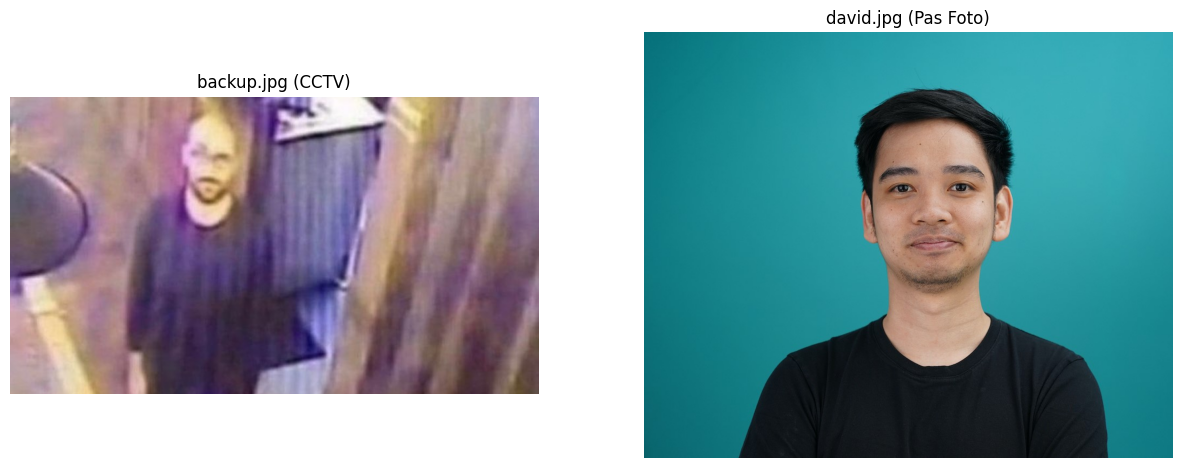

In [61]:
backup = cv.imread('backup.jpg')
david  = cv.imread('david.jpg')

backup_gray = cv.cvtColor(backup, cv.COLOR_BGR2GRAY)
david_gray  = cv.cvtColor(david,  cv.COLOR_BGR2GRAY)

backup_rgb = cv.cvtColor(backup, cv.COLOR_BGR2RGB)
david_rgb  = cv.cvtColor(david,  cv.COLOR_BGR2RGB)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(backup_rgb)
plt.title('backup.jpg (CCTV)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(david_rgb)
plt.title('david.jpg (Pas Foto)')
plt.axis('off')

Kode di atas digunakan untuk membaca dan menampilkan dua citra yaitu backup.jpg dan david.jpg.

cv.imread() digunakan untuk membaca gambar dari file.

cv.cvtColor() digunakan untuk mengubah format warna citra.
Perubahan BGR ke grayscale digunakan agar citra menjadi abu-abu, sedangkan perubahan BGR ke RGB digunakan agar warna gambar tampil normal saat ditampilkan menggunakan Matplotlib.

plt.figure(figsize=(15, 6)) digunakan untuk mengatur ukuran tampilan gambar.

plt.subplot(1, 2, ...) digunakan untuk membagi canvas menjadi 1 baris dan 2 kolom.

plt.imshow() digunakan untuk menampilkan citra.

plt.title() digunakan untuk memberikan judul pada gambar.

plt.axis(off) digunakan untuk menyembunyikan sumbu koordinat pada tampilan gambar.

---
## 1. Fungsi Dasar

In [62]:
def convolution(img, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(img, pad_size, mode='constant')
    canvas   = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

Kode di atas digunakan untuk melakukan konvolusi pada citra menggunakan kernel tertentu.

size digunakan untuk mengambil ukuran kernel, sedangkan pad_size digunakan untuk menentukan padding pada citra.

np.pad() digunakan untuk menambahkan padding di tepi citra.

np.zeros_like() digunakan untuk membuat canvas kosong sebagai tempat hasil konvolusi.

Perulangan for digunakan untuk memproses setiap piksel citra.

region digunakan untuk mengambil area citra sesuai ukuran kernel.

np.sum(region * kernel) digunakan untuk menghitung hasil konvolusi dan menyimpannya ke dalam canvas.

### 1.2 Filter Spasial (Mean / Median / Modus)

In [63]:
def filter_spasial(img, size, mode):
    height, width = img.shape
    pad    = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for row in region:
                        for pixel in row:
                            total += int(pixel)
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = []
                    for row in region:
                        for pixel in row:
                            values.append(int(pixel))
                    # bubble sort manual
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        count[val] = count.get(val, 0) + 1
                    max_count = 0
                    mode_val  = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val  = val
                    canvas[i, j] = mode_val

    return canvas

Kode di atas digunakan untuk melakukan filtering spasial pada citra dengan metode mean, median, dan modus. Fungsi menerima input berupa citra, ukuran kernel, dan jenis filter yang digunakan. np.pad() digunakan untuk menambahkan padding pada tepi citra, sedangkan np.zeros_like() digunakan untuk membuat canvas kosong sebagai tempat hasil filtering. Perulangan for digunakan untuk memproses setiap piksel berdasarkan area kernel. Pada mode mean, nilai piksel dihitung dari rata-rata area kernel. Pada mode median, data diurutkan menggunakan bubble sort lalu diambil nilai tengahnya. Pada mode modus, nilai piksel yang paling sering muncul pada area kernel digunakan sebagai hasil filtering.

### 1.3 Deteksi Tepi & Threshold

In [64]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / (np.max(canvas) + 1e-8)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Kode di atas digunakan untuk melakukan deteksi tepi pada citra menggunakan kernel horizontal dan vertikal. Fungsi convolution() digunakan untuk menghitung gradien pada sumbu x dan y. np.abs() digunakan untuk mengambil nilai absolut dari hasil gradien, kemudian kedua hasil dijumlahkan untuk mendapatkan tepi citra. Nilai hasil kemudian dinormalisasi ke rentang 0–255 dan diubah menjadi tipe uint8 agar dapat ditampilkan sebagai citra grayscale.

### 1.4 Definisi Semua Kernel

In [65]:
# ── Perbaikan Citra ─────────────────────────────────────────────────
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

#  Sobel 
sobelX = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)

sobelY = np.array([[ 1,  2,  1],
                   [ 0,  0,  0],
                   [-1, -2, -1]], dtype=np.float32)

#  Prewitt 
prewittX = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]], dtype=np.float32)

prewittY = np.array([[ 1,  1,  1],
                     [ 0,  0,  0],
                     [-1, -1, -1]], dtype=np.float32)

#  Roberts
robertsX = np.array([[ 1,  0],
                     [ 0, -1]], dtype=np.float32)

robertsY = np.array([[ 0,  1],
                     [-1,  0]], dtype=np.float32)

kode diatas untuk mendefinisikan kernel atau rumus yang digunakan untuk kalkulasi dari setiap piksel nantinya

## 2. CCTV – Smoothing, Sharpening, dan Kombinasi

**Pertanyaan:**
1. Apakah perbedaan antara ke-3 metode tersebut? Jelaskan kegunaan dan perbedaannya!
2. Apa perbedaan hasil dari Mean, Median, dan Modus?

**Jawaban:**
- **Smoothing** menghaluskan citra dengan merata-ratakan piksel sekitarnya, sehingga noise berkurang namun tepi menjadi sedikit buram.
- **Sharpening** mempertajam detail tepi dengan menguatkan perbedaan intensitas antar piksel.
- **Smooth + Sharp** (kombinasi) menggabungkan kedua efek: noise direduksi lebih dulu, lalu tepi diperkuat sehingga detail lebih menonjol daripada hanya sharpening langsung.

Perbedaan filter spasial:
- **Mean** menghitung rata-rata, efektif mengurangi noise Gaussian namun membuat tepi buram.
- **Median** mengambil nilai tengah setelah diurutkan, sangat efektif untuk salt-and-pepper noise dan lebih mempertahankan tepi.
- **Modus** mengambil nilai piksel yang paling sering muncul dalam window, cocok untuk citra dengan area warna seragam.

In [66]:
backup_smoothing  = convolution(backup_gray, kernelSmoothing)
backup_sharpening = convolution(backup_gray, kernelSharpening)
backup_smoosharp  = backup_smoothing + backup_sharpening

Kode di atas digunakan untuk melakukan proses smoothing dan sharpening pada citra grayscale. Fungsi convolution() digunakan untuk menerapkan kernel smoothing dan kernel sharpening pada citra backup_gray. Hasil smoothing disimpan pada backup_smoothing, hasil sharpening disimpan pada backup_sharpening, kemudian kedua hasil digabungkan menggunakan operasi penjumlahan dan disimpan pada backup_smoosharp.

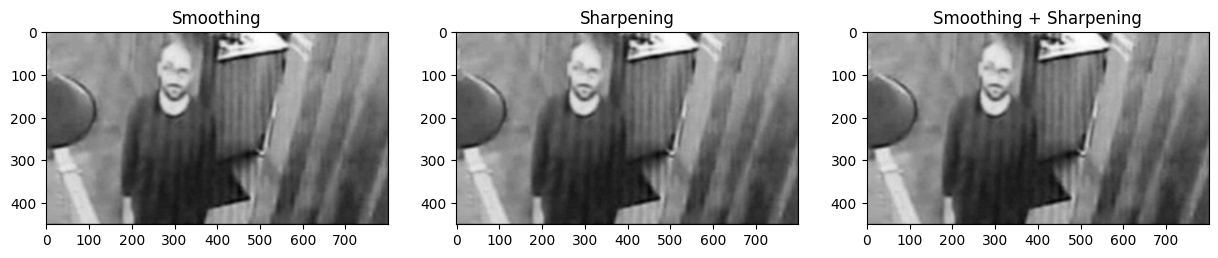

In [67]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Smoothing")
plt.imshow(backup_smoothing, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Sharpening")
plt.imshow(backup_smoothing, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Smoothing + Sharpening')
plt.imshow(backup_smoosharp, cmap='gray')


kode di atas ialah untuk menampilkan citra yang sudah didefinisikan sebelumnya

In [68]:
backup_mean   = filter_spasial(backup_gray, 3, 'mean')
backup_median = filter_spasial(backup_gray, 3, 'median')
backup_modus  = filter_spasial(backup_gray, 3, 'modus')

kode diatas untuk menghitung perbedaan dari penggunaan filter dengan mode mean, median dan modus

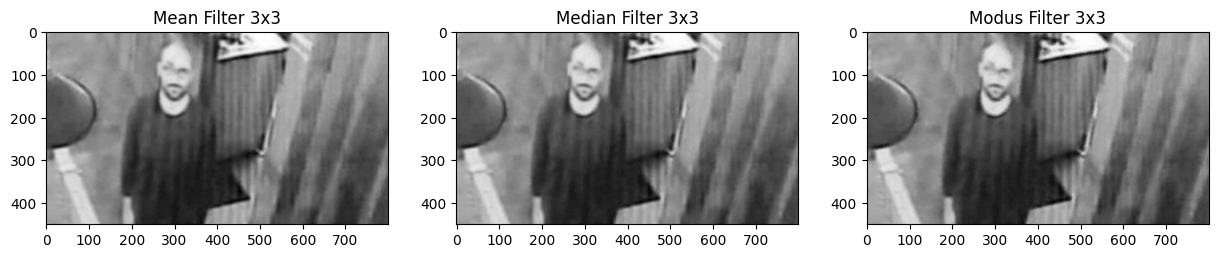

In [69]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Mean Filter 3x3")
plt.imshow(backup_mean, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Median Filter 3x3")
plt.imshow(backup_median, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Modus Filter 3x3')
plt.imshow(backup_modus, cmap='gray')

In [70]:
print(backup_mean)
print(backup_median)
print(backup_modus)

[[169 171 173 ... 169 169 168]
 [171 173 175 ... 168 168 167]
 [174 175 177 ... 168 166 166]
 ...
 [168 168 167 ...  83  83  82]
 [168 168 168 ...  83  83  82]
 [168 168 167 ...  83  83  83]]
[[170 171 173 ... 170 169 169]
 [171 173 176 ... 169 168 167]
 [174 176 178 ... 168 167 166]
 ...
 [168 168 168 ...  84  83  83]
 [168 168 168 ...  84  83  83]
 [168 168 168 ...  84  83  83]]
[[168 173 173 ... 170 170 169]
 [168 173 173 ... 170 170 169]
 [171 178 178 ... 169 168 165]
 ...
 [168 168 168 ...  84  83  83]
 [168 168 168 ...  84  83  83]
 [168 168 168 ...  84  83  83]]


kode diatas ialah menampilkan perbedaan dari penggunaan filter median dan modus. Secara kasat mata sebenarnya tidak terlihat perbedaan yang banyak tapi untuk setiap piksel yang ada punya sedikit pergeseran nilai dan karena hanya bergeser sedikit ini membuatnya tampak tidak berbeda

---
## 3. CCTV – Deteksi Tepi dan Kombinasi Operator

**Pertanyaan:** Jelaskan kegunaan operator dan kombinasi dari operator-operator tersebut!

**Jawaban:**
- **Prewitt** mendeteksi tepi horizontal dan vertikal dengan bobot seragam, sensitif terhadap tepi namun lebih mudah terpengaruh noise.
- **Sobel** mirip Prewitt namun memberi bobot lebih besar pada piksel pusat, sehingga lebih halus dan tahan terhadap noise.
- **Roberts** menggunakan kernel 2x2 diagonal, sangat sensitif terhadap tepi diagonal namun juga sensitif terhadap noise.
- **Kombinasi** (penjumlahan + normalisasi) mengakomodasi tepi dari berbagai arah yang mungkin terlewat oleh satu operator, menghasilkan deteksi yang lebih lengkap.

In [71]:
edge_prewitt = edge(backup_smoosharp, prewittX, prewittY)
edge_sobel   = edge(backup_smoosharp, sobelX,   sobelY)
edge_roberts = edge(backup_smoosharp, robertsX, robertsY)

kode di atas untuk memanggil fungsi edge() yang sudah didefinisikan sebelumnya dan disimpan pada variabel yang memanggilnya tersebut

In [72]:
def norm255(img):
    img = img.astype(np.float32)
    return np.clip(img * 255.0 / (np.max(img) + 1e-8), 0, 255).astype(np.uint8)

Kode di atas digunakan untuk melakukan normalisasi nilai piksel citra ke rentang 0–255. Citra terlebih dahulu diubah ke tipe float32 agar perhitungan lebih akurat. Nilai piksel kemudian diskalakan berdasarkan nilai maksimum citra menggunakan operasi perkalian dan pembagian. np.clip() digunakan untuk memastikan nilai tetap berada pada rentang 0–255, lalu hasil akhir diubah menjadi tipe uint8.

In [73]:

edge_prewitt_sobel          = norm255(edge_prewitt.astype(np.float32) + edge_sobel.astype(np.float32))
edge_prewitt_roberts        = norm255(edge_prewitt.astype(np.float32) + edge_roberts.astype(np.float32))
edge_sobel_roberts          = norm255(edge_sobel.astype(np.float32)   + edge_roberts.astype(np.float32))
edge_prewitt_sobel_roberts  = norm255(edge_prewitt.astype(np.float32) + edge_sobel.astype(np.float32) + edge_roberts.astype(np.float32))

Kode di atas digunakan untuk menggabungkan hasil deteksi tepi dari metode Prewitt, Sobel, dan Roberts. Setiap citra tepi terlebih dahulu diubah ke tipe float32 agar proses penjumlahan lebih aman dan akurat. Hasil penggabungan kemudian dinormalisasi menggunakan fungsi norm255() agar nilai piksel kembali berada pada rentang 0–255.

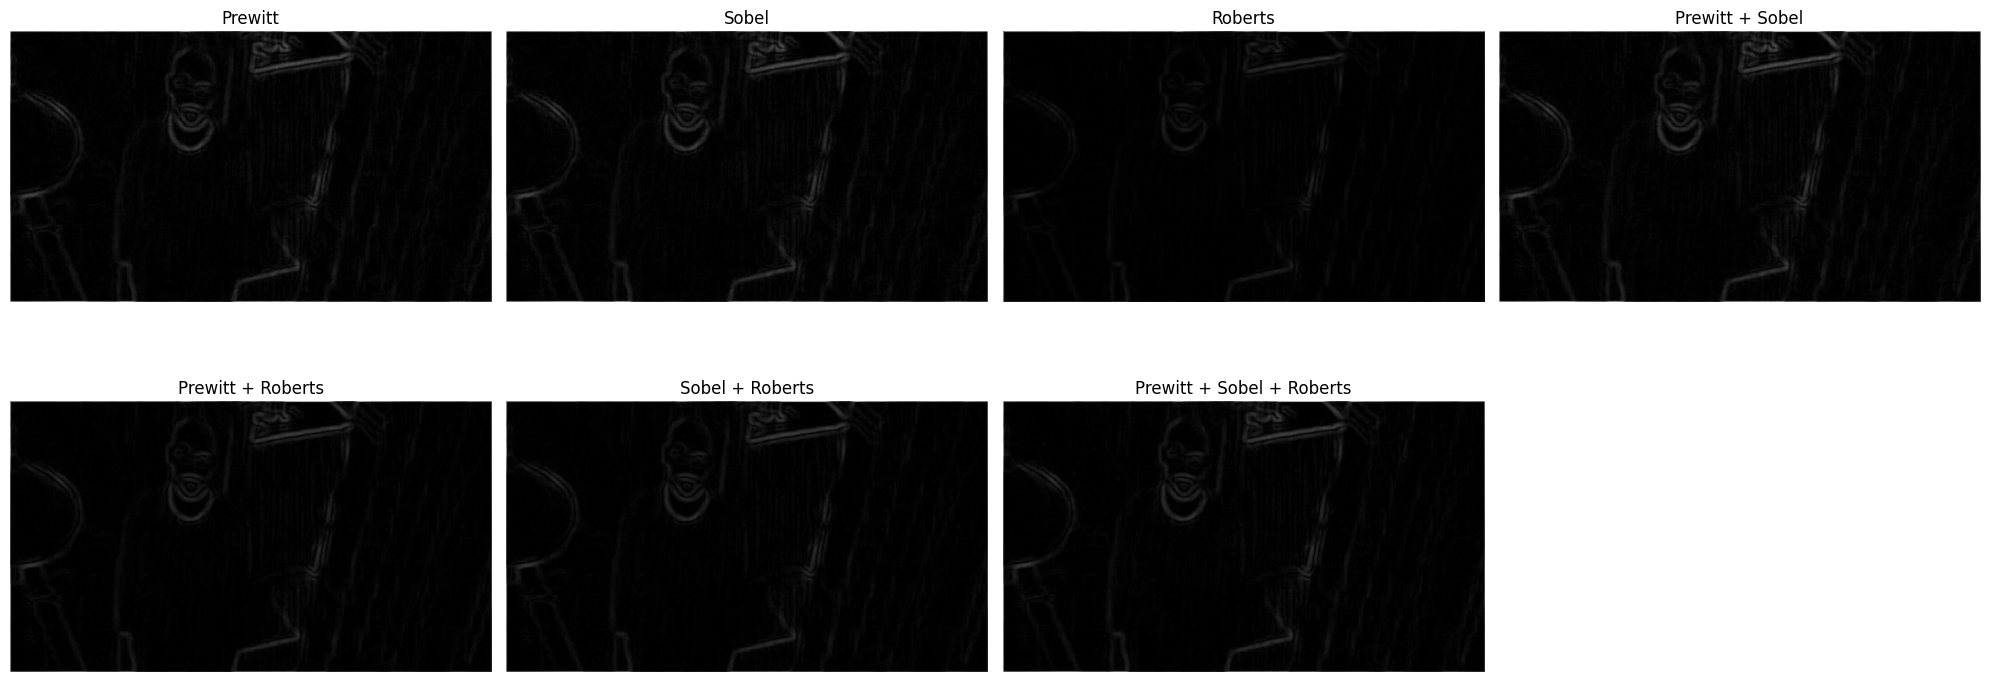

In [74]:
plt.figure(figsize=(20, 8))

plt.subplot(2, 4, 1)
plt.title("Prewitt")
plt.imshow(edge_prewitt, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.title("Sobel")
plt.imshow(edge_sobel, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.title("Roberts")
plt.imshow(edge_roberts, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.title("Prewitt + Sobel")
plt.imshow(edge_prewitt_sobel, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.title("Prewitt + Roberts")
plt.imshow(edge_prewitt_roberts, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.title("Sobel + Roberts")
plt.imshow(edge_sobel_roberts, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.title("Prewitt + Sobel + Roberts")
plt.imshow(edge_prewitt_sobel_roberts, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

kode diatas untuk menampilkan citra, menggunakan plt.figure agar tampilanya menyesuaikan canvas yang sudah dibuat

---
## 4. CCTV – Perbandingan Threshold Tepi

**Pertanyaan:** Jelaskan pengaruh threshold. Apa perbedaan mencolok threshold rendah dan tinggi? Berapa nilai threshold paling bagus?

**Jawaban:**
- **Threshold rendah (10-20):** Banyak tepi terdeteksi termasuk noise, gambar tampak banyak garis putih.
- **Threshold tinggi (50-60):** Hanya tepi yang sangat kuat yang muncul, banyak detail hilang.
- **Threshold optimal untuk citra CCTV ini: 20-30**, karena masih menampilkan bentuk/siluet subjek dengan cukup jelas tanpa terlalu banyak noise. Ini adalah kompromi antara kelengkapan tepi dan kebersihan gambar.

In [75]:
def threshold(img, nilai):
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            canvas[i, j] = 255 if img[i, j] >= nilai else 0
    return canvas

Kode di atas digunakan untuk melakukan thresholding pada citra. np.zeros_like() digunakan untuk membuat canvas kosong sebagai tempat hasil threshold. Perulangan for digunakan untuk memeriksa setiap piksel citra. Jika nilai piksel lebih besar atau sama dengan nilai threshold, maka piksel diubah menjadi 255, sedangkan jika lebih kecil akan diubah menjadi 0. Hasil akhir disimpan pada canvas.

In [76]:
threshold_10 = threshold(edge_prewitt, 10)
threshold_20 = threshold(edge_prewitt, 20)
threshold_30 = threshold(edge_prewitt, 30)
threshold_40 = threshold(edge_prewitt, 40)
threshold_50 = threshold(edge_prewitt, 50)
threshold_60 = threshold(edge_prewitt, 60)

kode diatas untuk melakukan pemanggilan fungsi threshold(), kemudian disimpan pada variabell yang sesuai

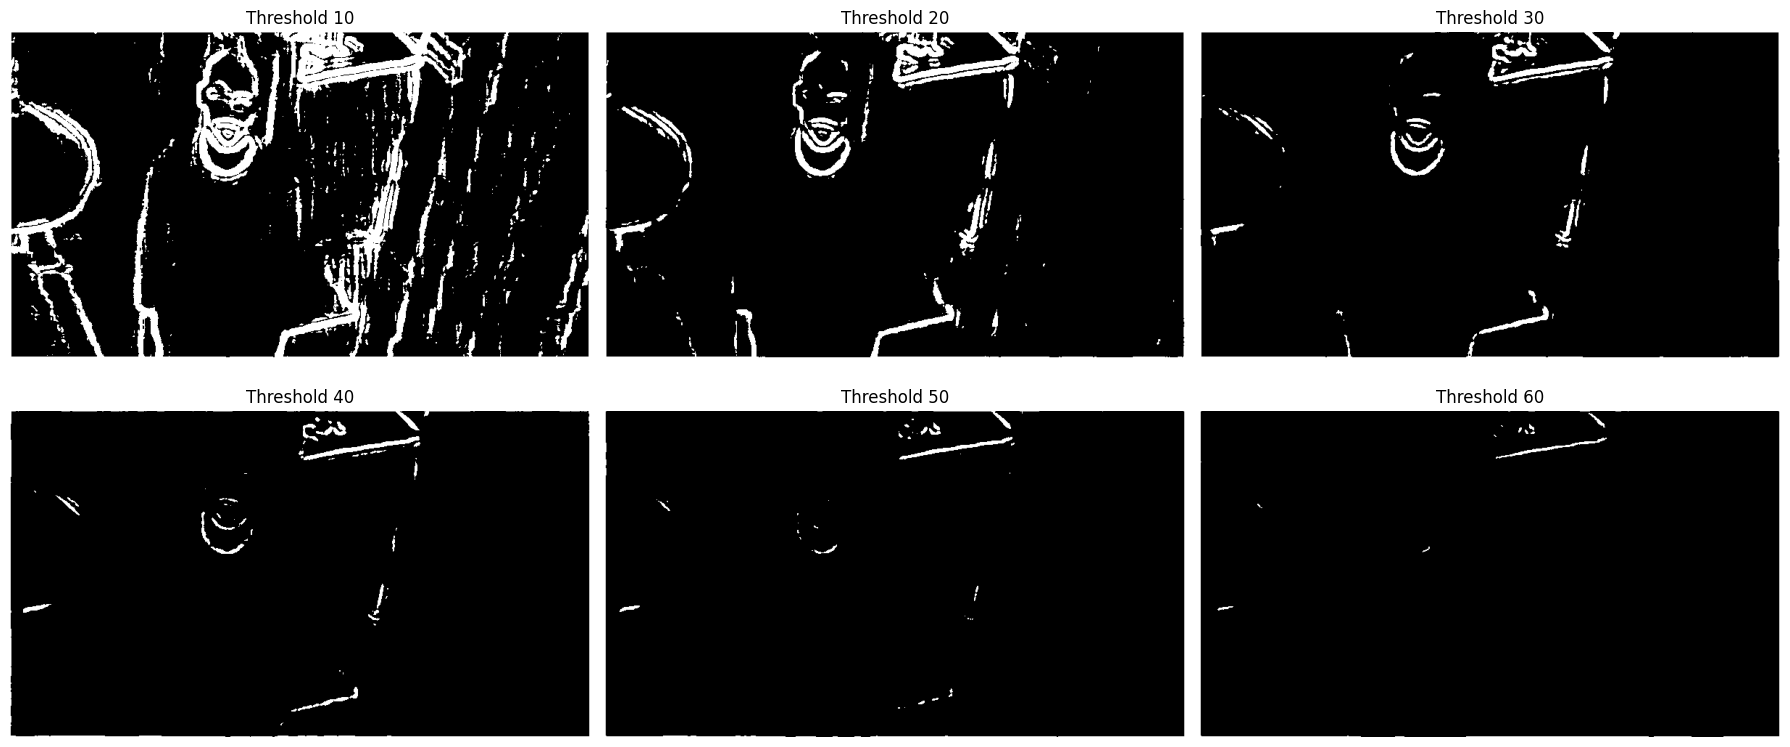

In [77]:
plt.figure(figsize=(18, 8))

plt.subplot(2, 3, 1)
plt.title("Threshold 10")
plt.imshow(threshold_10, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Threshold 20")
plt.imshow(threshold_20, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Threshold 30")
plt.imshow(threshold_30, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Threshold 40")
plt.imshow(threshold_40, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Threshold 50")
plt.imshow(threshold_50, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Threshold 60")
plt.imshow(threshold_60, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

dari hasil pemanggilan sebelumnya, kode di atas untuk menampilkan hasil kode yang disimpan

---
## 5. CCTV – Highlight Siluet Orang

Tujuan: menonjolkan area orang pada citra CCTV menggunakan masking.
Mask dibangun dari threshold gelap (subjek lebih gelap dari background), dilanjutkan dengan dilasi, erosi, dan flood fill untuk mendapatkan objek terbesar.

In [78]:
def dilasiCitra(mask, ukuran=1):
    tinggi, lebar = mask.shape
    hasil = np.zeros_like(mask)
    for y in range(tinggi):
        for x in range(lebar):
            if mask[y, x] > 0:
                for dy in range(-ukuran, ukuran + 1):
                    for dx in range(-ukuran, ukuran + 1):
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < tinggi and 0 <= nx < lebar:
                            hasil[ny, nx] = 255
    return hasil

Kode di atas digunakan untuk melakukan proses dilasi pada citra biner. np.zeros_like() digunakan untuk membuat canvas kosong sebagai hasil dilasi. Perulangan for digunakan untuk memeriksa setiap piksel pada citra. Jika ditemukan piksel putih, maka piksel di sekitarnya sesuai ukuran kernel akan diubah menjadi putih sehingga area objek menjadi lebih besar.

In [79]:
def erosiCitra(mask, ukuran=1):
    tinggi, lebar = mask.shape
    hasil = np.zeros_like(mask)
    for y in range(tinggi):
        for x in range(lebar):
            semua_putih = True
            for dy in range(-ukuran, ukuran + 1):
                for dx in range(-ukuran, ukuran + 1):
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < tinggi and 0 <= nx < lebar:
                        if mask[ny, nx] == 0:
                            semua_putih = False
                    else:
                        semua_putih = False
            if semua_putih:
                hasil[y, x] = 255
    return hasil

Kode di atas digunakan untuk melakukan proses erosi pada citra biner. np.zeros_like() digunakan untuk membuat canvas kosong sebagai hasil erosi. Perulangan for digunakan untuk memeriksa setiap piksel beserta area di sekitarnya. Jika semua piksel pada area kernel bernilai putih, maka piksel pada hasil akan diisi 255. Jika ada piksel hitam, maka piksel tersebut tidak dipertahankan sehingga ukuran objek menjadi lebih kecil.

In [80]:
def floodFill(mask, visited, startY, startX):
    tinggi, lebar = mask.shape
    stack = [(startY, startX)]
    komponen = []
    while stack:
        y, x = stack.pop()
        if y < 0 or y >= tinggi or x < 0 or x >= lebar:
            continue
        if visited[y, x] or mask[y, x] == 0:
            continue
        visited[y, x] = True
        komponen.append((y, x))
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                stack.append((y + dy, x + dx))
    return komponen

Kode di atas digunakan untuk mencari kumpulan piksel yang saling terhubung pada citra biner menggunakan metode flood fill. Variabel stack digunakan untuk menyimpan posisi piksel yang akan diperiksa, sedangkan komponen digunakan untuk menyimpan piksel yang terhubung. Perulangan while digunakan untuk memeriksa setiap piksel di sekitar posisi awal. Jika piksel masih berada dalam batas citra, belum dikunjungi, dan bernilai putih, maka piksel akan ditandai sebagai visited dan dimasukkan ke dalam komponen. Hasil akhirnya berupa kumpulan koordinat piksel yang saling terhubung.

In [81]:
def ambilObjekTerbesar(mask):
    tinggi, lebar = mask.shape
    visited = np.zeros((tinggi, lebar), dtype=bool)
    terbesar = []
    for y in range(tinggi):
        for x in range(lebar):
            if mask[y, x] > 0 and not visited[y, x]:
                komp = floodFill(mask, visited, y, x)
                if len(komp) > len(terbesar):
                    terbesar = komp
    hasil = np.zeros_like(mask)
    for y, x in terbesar:
        hasil[y, x] = 255
    return hasil

Kode di atas digunakan untuk mengambil objek terbesar pada citra biner. np.zeros() digunakan untuk membuat array visited sebagai penanda piksel yang sudah diperiksa. Perulangan for digunakan untuk memeriksa setiap piksel citra. Jika ditemukan objek yang belum dikunjungi, maka fungsi floodFill() digunakan untuk mencari seluruh piksel yang terhubung. Objek dengan jumlah piksel terbanyak akan disimpan sebagai objek terbesar. Hasil akhirnya disimpan pada canvas hasil dengan piksel objek bernilai 255.

In [82]:
def thresholdGelap(img, nilai=80):
    hasil = np.zeros_like(img)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            hasil[y, x] = 255 if img[y, x] < nilai else 0
    return hasil

Kode di atas digunakan untuk melakukan thresholding pada area gelap citra. np.zeros_like() digunakan untuk membuat canvas kosong sebagai hasil threshold. Perulangan for digunakan untuk memeriksa setiap piksel citra. Jika nilai piksel lebih kecil dari nilai threshold, maka piksel akan diubah menjadi 255, sedangkan piksel lainnya diubah menjadi 0. Hasil akhirnya disimpan pada variabel hasil.

In [83]:
def highlightSiluet(citraRGB, maskSolid, maskTepi, alpha=0.4):
    hasil = citraRGB.copy()
    h, w, _ = hasil.shape
    for y in range(h):
        for x in range(w):
            if maskSolid[y, x] > 0:
                hasil[y, x, 0] = min(255, int((1 - alpha) * hasil[y, x, 0] + alpha * 255))
                hasil[y, x, 1] = min(255, int((1 - alpha) * hasil[y, x, 1] + alpha * 255))
                hasil[y, x, 2] = int((1 - alpha) * hasil[y, x, 2])
            if maskTepi[y, x] > 0:
                hasil[y, x] = [255, 255, 0]
    return hasil

Kode di atas digunakan untuk memberikan highlight pada objek dan tepi objek pada citra RGB. copy() digunakan untuk menyalin citra asli agar data awal tidak berubah. Perulangan for digunakan untuk memeriksa setiap piksel citra. Jika piksel termasuk area objek pada maskSolid, maka warna piksel akan dicampur dengan warna terang menggunakan nilai alpha. Jika piksel termasuk area tepi pada maskTepi, maka warna piksel diubah menjadi kuning dengan nilai RGB [255, 255, 0]. Hasil akhirnya disimpan pada variabel hasil.

In [90]:
tinggiImg, lebarImg = backup_gray.shape

# === MASK BADAN ===
maskBadan = thresholdGelap(backup_gray, 120)
maskBadan = ambilObjekTerbesar(maskBadan)
maskBadan = dilasiCitra(maskBadan, 6)
maskBadan = erosiCitra(maskBadan, 4)
# Hapus area kepala dari mask badan
maskBadan[:160, :] = 0

# === MASK KEPALA ===
maskKepala = np.zeros_like(backup_gray, dtype=np.uint8)
for y in range(25, 200):
    for x in range(260, 330):
        if backup_gray[y, x] >= 115:
            maskKepala[y, x] = 255
maskKepala = erosiCitra(maskKepala, 1)
maskKepala = dilasiCitra(maskKepala, 6)

# === GABUNG MASK ===
maskGabung = np.zeros_like(backup_gray)
for y in range(tinggiImg):
    for x in range(lebarImg):
        if maskBadan[y, x] > 0 or maskKepala[y, x] > 0:
            maskGabung[y, x] = 255

# === CLEANING ===
maskSolid = ambilObjekTerbesar(maskGabung)
maskSolid[:, 390:] = 0  # potong tepi kanan yang bukan subjek
maskSolid = ambilObjekTerbesar(maskSolid)

# === DETEKSI TEPI MASK ===
maskTepi = edge(maskSolid, sobelX, sobelY)
maskTepi = threshold(maskTepi, 50)

# === HIGHLIGHT ===
hasilHighlight = highlightSiluet(backup_rgb, maskSolid, maskTepi, 0.4)

Kode di atas digunakan untuk melakukan segmentasi dan highlight pada objek manusia pada citra backup_gray. Proses dimulai dengan membuat mask badan menggunakan thresholdGelap(), kemudian dilakukan dilasi dan erosi untuk memperbaiki bentuk objek. Area kepala pada mask badan dihapus agar dapat diproses terpisah. Selanjutnya dibuat mask kepala dengan memeriksa area tertentu pada citra berdasarkan nilai piksel. Kedua mask kemudian digabung menjadi maskGabung. Setelah itu dilakukan cleaning menggunakan ambilObjekTerbesar() untuk mengambil objek utama dan menghapus bagian yang tidak diperlukan. Deteksi tepi dilakukan menggunakan fungsi edge() dan threshold(). Terakhir, fungsi highlightSiluet() digunakan untuk memberikan highlight pada objek dan tepinya pada citra RGB.

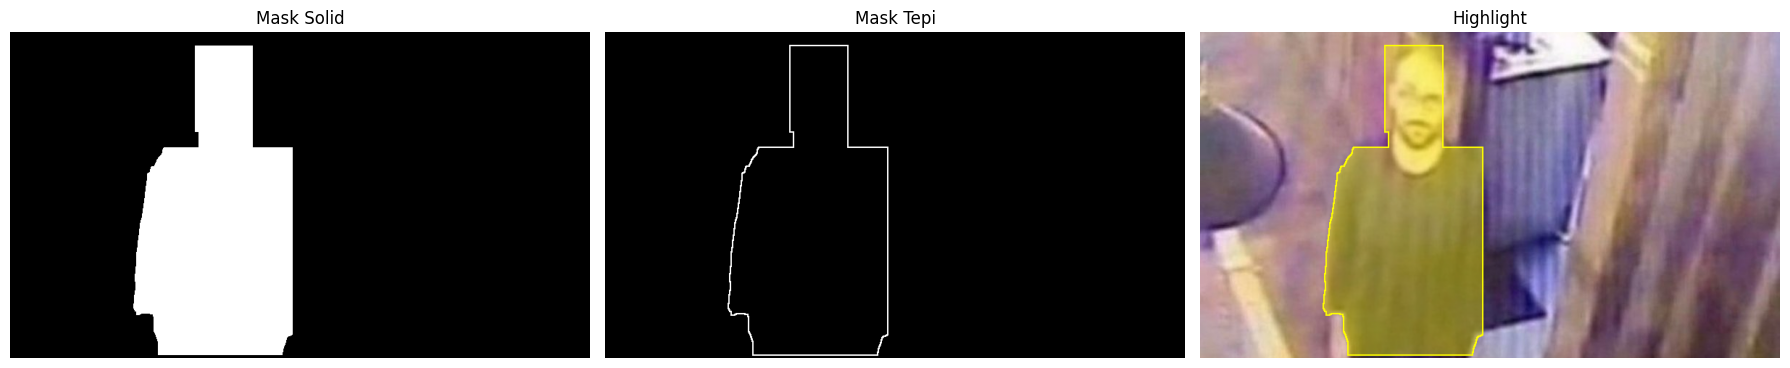

In [89]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(maskSolid, cmap='gray')
plt.title("Mask Solid")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(maskTepi, cmap='gray')
plt.title("Mask Tepi")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasilHighlight)
plt.title("Highlight")
plt.axis('off')

plt.tight_layout()
plt.show()

kode diatas untuk menampilkan citra

---
## 6. Pas Foto – Deteksi Tepi dan Background Removal

**Pertanyaan:** Jelaskan proses perubahan dari citra awal hingga ke bagian penghilangan background.

**Jawaban:**
1. **Load & Grayscale** – Citra `david.jpg` dimuat dan dikonversi grayscale.
2. **Median Filter** – Noise kecil dihilangkan dengan median 3x3 sebelum deteksi tepi.
3. **Deteksi Tepi (Sobel)** – Diterapkan pada citra yang sudah di-smooth untuk mendapatkan kontur wajah, rambut, dan pakaian.
4. **Pemisahan Background (RGB Thresholding)** – Kanal R, G, B dipisahkan. Background toska diidentifikasi dengan kondisi: `G > R + 10` dan `B > R` dan nilai G serta B cukup tinggi.
5. **Masking Foreground** – Piksel background dibuat putih, foreground dipertahankan sesuai citra asli.

In [85]:
def gabung(imageAwal, imageGabung):
    h, w = imageAwal.shape[:2]
    hasil_gabung = np.full((h, w, 3), 255, dtype=np.uint8)  # kanvas putih

    # buat mask 2D
    if imageAwal.shape[:2] == imageAwal.shape:
        mask = imageAwal > 0
    else:
        mask = np.mean(imageAwal, axis=2) > 0

    hasil_gabung[mask] = imageGabung[mask]
    return hasil_gabung

Kode di atas digunakan untuk menggabungkan dua citra berdasarkan mask tertentu. np.full() digunakan untuk membuat canvas putih sebagai hasil awal. Program kemudian membuat mask 2D dengan memeriksa apakah citra awal berupa grayscale atau RGB. Jika nilai piksel pada mask lebih besar dari 0, maka piksel dari imageGabung akan disalin ke hasil_gabung. Hasil akhirnya berupa citra gabungan dengan background putih.

In [86]:
david_median = filter_spasial(david_gray, 3, 'median')
david_edge   = edge(david_median, sobelX, sobelY)

R = david_rgb[:, :, 0].astype(float)
G = david_rgb[:, :, 1].astype(float)
B = david_rgb[:, :, 2].astype(float)

mask_bg = (G > R + 10) & (B > R) & (G > 95) & (B > 80)

mask_fg = np.zeros_like(david_gray)
mask_fg[~mask_bg] = 255

david_putih = gabung(mask_fg, david_rgb)

Kode di atas digunakan untuk menghilangkan background pada citra david_rgb. Citra grayscale terlebih dahulu difilter menggunakan median filter untuk mengurangi noise, kemudian dilakukan deteksi tepi menggunakan fungsi edge(). Nilai channel R, G, dan B dipisahkan untuk mendeteksi background berdasarkan dominasi warna tertentu. Mask background dibuat menggunakan kondisi threshold warna, lalu dibalik menjadi mask foreground. Fungsi gabung() digunakan untuk mempertahankan objek foreground dan mengganti background menjadi warna putih.

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

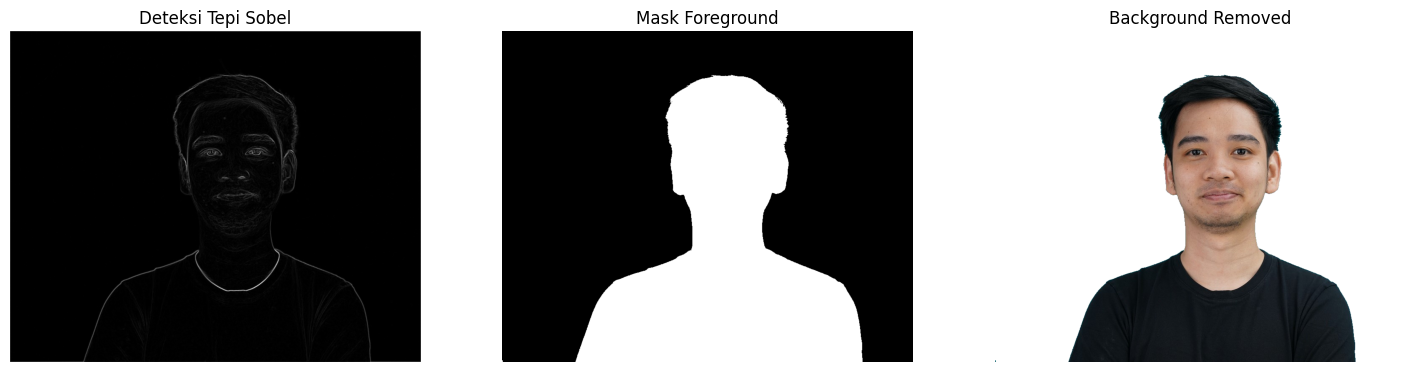

In [91]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(david_edge, cmap='gray')
plt.title("Deteksi Tepi Sobel")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_fg, cmap='gray')
plt.title("Mask Foreground")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(david_putih)
plt.title("Background Removed")
plt.axis('off')


kode di atas untuk menampilkan citra


---
## 7. Ringkasan – Analisis dan Kesimpulan

**Kesimpulan:**

Perbaikan kualitas citra dan deteksi tepi merupakan dua tahap esensial dalam pengolahan citra digital:

1. **Perbaikan kualitas** (smoothing, sharpening, filter spasial) berperan membersihkan noise dan meningkatkan kejelasan visual citra sebelum analisis lebih lanjut. Tanpa tahap ini, noise dapat terbaca sebagai tepi palsu.

2. **Deteksi tepi** (Sobel, Prewitt, Roberts) mengekstrak informasi bentuk/kontur dari objek, yang sangat berguna untuk segmentasi, identifikasi objek, dan analisis siluet — seperti yang diterapkan pada citra CCTV untuk menonjolkan subjek.

3. **Threshold** mengontrol sensitivitas deteksi: nilai rendah menangkap lebih banyak tepi (termasuk noise), nilai tinggi hanya mempertahankan tepi kuat. Pemilihan threshold yang tepat bergantung pada kualitas citra dan kebutuhan analisis.

4. **Background removal** berbasis threshold RGB menunjukkan bahwa informasi warna dapat dimanfaatkan untuk memisahkan subjek dari latar secara sederhana tanpa model kompleks.
